In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_v3 = pd.read_csv("../data/processed/cleaned_uhi_v3.csv")

print("Dataset V3 loaded successfully")
print("Shape:", df_v3.shape)
display(df_v3.head())

Dataset V3 loaded successfully
Shape: (9893, 8)


,Elevation,LST,LandCover,Latitude,Longitude,NDBI,NDVI,Population
0,919,43.919170,40,19.970832,75.438700,0.127207,0.162286,1.562392
1,488,39.060455,40,19.729093,75.209548,-0.272423,0.570751,1.361367
2,505,40.231127,30,19.788775,75.225639,0.055877,0.099371,15.386780
3,757,44.884761,40,19.960297,75.544582,0.121404,0.196037,2.643492
4,586,48.502735,30,19.867709,75.486062,0.133151,0.165262,31.397209


In [2]:
print("Column names:")
print(df_v3.columns.tolist())

print("\nMissing values:")
print(df_v3.isnull().sum())

print("\nDuplicate rows:")
print(df_v3.duplicated().sum())

Column names:
['Elevation', 'LST', 'LandCover', 'Latitude', 'Longitude', 'NDBI', 'NDVI', 'Population']

Missing values:
Elevation     0
LST           0
LandCover     0
Latitude      0
Longitude     0
NDBI          0
NDVI          0
Population    0
dtype: int64

Duplicate rows:
0


In [3]:
numeric_columns = [
    "Elevation",
    "LST",
    "Latitude",
    "Longitude",
    "NDBI",
    "NDVI",
    "Population"
]

v3_numeric_summary = df_v3[numeric_columns].describe().T
v3_numeric_summary

,count,mean,std,min,25%,50%,75%,max
Elevation,9893.0,621.370262,85.589970,483.000000,556.000000,597.000000,691.000000,926.000000
LST,9893.0,43.463630,3.229270,27.762190,41.241152,43.606422,45.966564,51.956644
Latitude,9893.0,19.890409,0.085958,19.723374,19.819395,19.892116,19.963205,20.042864
Longitude,9893.0,75.357082,0.118384,75.142142,75.255050,75.356124,75.454214,75.586524
NDBI,9893.0,0.029918,0.098665,-0.433368,-0.021819,0.053535,0.099973,0.401310
NDVI,9893.0,0.241080,0.115880,-0.128937,0.160441,0.211398,0.296107,0.751738
Population,9893.0,12.378498,29.300305,0.667908,2.063318,3.155722,7.110859,230.774673


In [4]:
landcover_labels = {
    10: "Tree cover",
    20: "Shrubland",
    30: "Grassland",
    40: "Cropland",
    50: "Built-up land",
    60: "Bare/sparse vegetation",
    80: "Permanent water bodies"
}

landcover_counts_v3 = (
    df_v3["LandCover"]
    .value_counts()
    .sort_index()
    .rename_axis("LandCover")
    .reset_index(name="Pixel_Count")
)

landcover_counts_v3["LandCover_Name"] = (
    landcover_counts_v3["LandCover"].map(landcover_labels)
)

landcover_counts_v3["Percentage"] = (
    landcover_counts_v3["Pixel_Count"] / len(df_v3) * 100
).round(2)

landcover_counts_v3

,LandCover,Pixel_Count,LandCover_Name,Percentage
0,10,483,Tree cover,4.88
1,20,714,Shrubland,7.22
2,30,2421,Grassland,24.47
3,40,5253,Cropland,53.10
4,50,839,Built-up land,8.48
5,60,154,Bare/sparse vegetation,1.56
6,80,29,Permanent water bodies,0.29


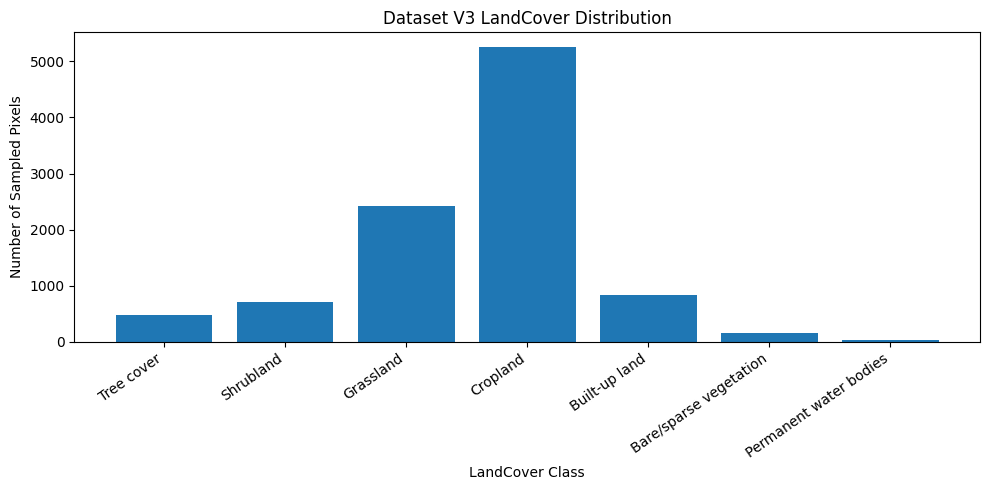

In [5]:
plt.figure(figsize=(10, 5))

plt.bar(
    landcover_counts_v3["LandCover_Name"],
    landcover_counts_v3["Pixel_Count"]
)

plt.title("Dataset V3 LandCover Distribution")
plt.xlabel("LandCover Class")
plt.ylabel("Number of Sampled Pixels")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [6]:
lst_by_landcover = (
    df_v3.groupby("LandCover")["LST"]
    .agg(["count", "mean", "median", "min", "max", "std"])
    .round(2)
    .reset_index()
)

lst_by_landcover["LandCover_Name"] = (
    lst_by_landcover["LandCover"].map(landcover_labels)
)

lst_by_landcover = lst_by_landcover[
    [
        "LandCover",
        "LandCover_Name",
        "count",
        "mean",
        "median",
        "min",
        "max",
        "std"
    ]
].sort_values("mean", ascending=False)

lst_by_landcover

,LandCover,LandCover_Name,count,mean,median,min,max,std
2,30,Grassland,2421,45.76,46.03,37.31,51.96,2.25
5,60,Bare/sparse vegetation,154,45.28,45.57,30.61,50.23,2.91
1,20,Shrubland,714,43.06,43.36,28.38,50.22,2.70
3,40,Cropland,5253,42.87,42.94,31.65,51.72,3.21
4,50,Built-up land,839,42.79,42.69,37.03,49.30,1.89
0,10,Tree cover,483,40.21,40.08,34.56,48.43,2.53
6,80,Permanent water bodies,29,34.01,33.64,27.76,44.88,5.42


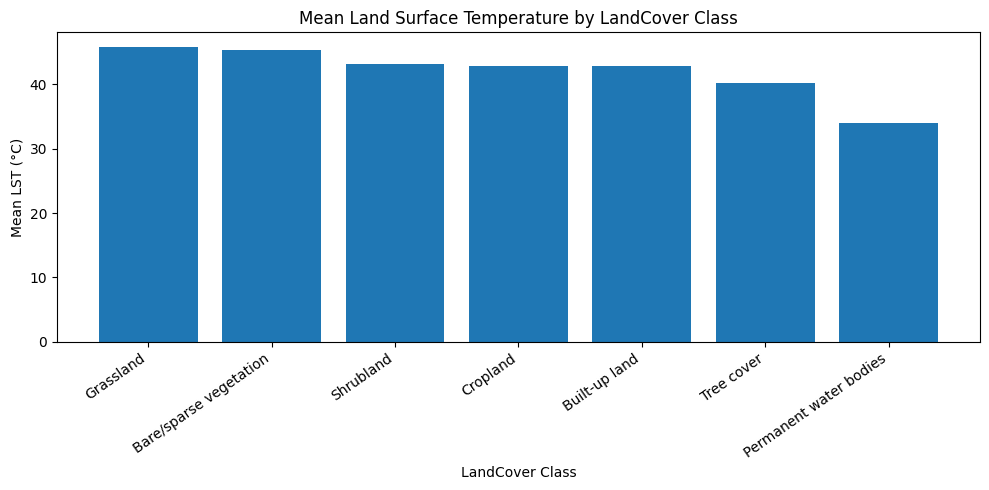

In [7]:
plt.figure(figsize=(10, 5))

plt.bar(
    lst_by_landcover["LandCover_Name"],
    lst_by_landcover["mean"]
)

plt.title("Mean Land Surface Temperature by LandCover Class")
plt.xlabel("LandCover Class")
plt.ylabel("Mean LST (°C)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [8]:
indices_by_landcover = (
    df_v3.groupby("LandCover")[["NDVI", "NDBI"]]
    .mean()
    .round(3)
    .reset_index()
)

indices_by_landcover["LandCover_Name"] = (
    indices_by_landcover["LandCover"].map(landcover_labels)
)

indices_by_landcover = indices_by_landcover[
    ["LandCover", "LandCover_Name", "NDVI", "NDBI"]
]

indices_by_landcover

,LandCover,LandCover_Name,NDVI,NDBI
0,10,Tree cover,0.389,-0.061
1,20,Shrubland,0.273,0.070
2,30,Grassland,0.183,0.100
3,40,Cropland,0.265,-0.002
4,50,Built-up land,0.178,0.044
5,60,Bare/sparse vegetation,0.113,0.069
6,80,Permanent water bodies,0.028,-0.040


In [9]:
correlation_columns = [
    "NDVI",
    "NDBI",
    "Elevation",
    "Population",
    "LST"
]

v3_correlation = df_v3[correlation_columns].corr().round(3)

v3_correlation

,NDVI,NDBI,Elevation,Population,LST
NDVI,1.000,-0.775,-0.173,-0.101,-0.531
NDBI,-0.775,1.000,0.374,0.005,0.654
Elevation,-0.173,0.374,1.000,-0.172,0.272
Population,-0.101,0.005,-0.172,1.000,-0.106
LST,-0.531,0.654,0.272,-0.106,1.000


In [10]:
import os

os.makedirs("../outputs/reports", exist_ok=True)

landcover_counts_v3.to_csv(
    "../outputs/reports/v3_landcover_distribution.csv",
    index=False
)

lst_by_landcover.to_csv(
    "../outputs/reports/v3_lst_by_landcover.csv",
    index=False
)

indices_by_landcover.to_csv(
    "../outputs/reports/v3_indices_by_landcover.csv",
    index=False
)

v3_correlation.to_csv(
    "../outputs/reports/v3_continuous_feature_correlation.csv"
)

print("Saved V3 EDA outputs:")
print("outputs/reports/v3_landcover_distribution.csv")
print("outputs/reports/v3_lst_by_landcover.csv")
print("outputs/reports/v3_indices_by_landcover.csv")
print("outputs/reports/v3_continuous_feature_correlation.csv")

Saved V3 EDA outputs:
outputs/reports/v3_landcover_distribution.csv
outputs/reports/v3_lst_by_landcover.csv
outputs/reports/v3_indices_by_landcover.csv
outputs/reports/v3_continuous_feature_correlation.csv


## Dataset V3 EDA Conclusion

Dataset V3 retains the continuous environmental features from Dataset V2 and adds ESA WorldCover 2021 LandCover as a categorical surface-class feature.

LandCover was analyzed using class distribution, mean LST by class, and mean NDVI/NDBI by class. It was not included in the continuous correlation matrix because land-cover codes are categorical labels rather than ordered numeric values.

These results provide land-cover context for interpreting urban heat patterns. Dataset V3 will later be compared with Dataset V2 using the same spatial block cross-validation framework. No performance improvement is assumed before model evaluation.